In [104]:
# Q4.1 — Load Titanic dataset and create new_df with required columns

import pandas as pd

# Load dataset
df = pd.read_csv("titanic3.csv")

# Create new_df with required columns
new_df = df[['survived', 'pclass', 'sex', 'age']].copy()

# Drop rows with any NaN values
new_df=new_df.dropna()

print(new_df.isna().sum())

# Encode categorical column 'sex'
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
new_df['sex'] = label_encoder.fit_transform(new_df['sex'])


new_df.head()
df.describe()

survived    0
pclass      0
sex         0
age         0
dtype: int64


,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [105]:
# Q4.2 — Split into training and testing sets

from sklearn.model_selection import train_test_split

X = new_df[['pclass', 'sex', 'age']]
y = new_df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=20)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (732, 3)
Testing set: (314, 3)


In [106]:
# Q4.3 — Scale input features + train Decision Tree & Logistic Regression

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree model
dt_clf = DecisionTreeClassifier(random_state=20)
dt_clf.fit(X_train_scaled, y_train)

# Logistic Regression model
logreg = LogisticRegression(solver='liblinear', random_state=20)
logreg.fit(X_train_scaled, y_train)

print("Models trained successfully!")


Models trained successfully!


In [107]:
# Q4.4 — Evaluate the models

from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions
y_pred_dt = dt_clf.predict(X_test_scaled)
y_pred_lr = logreg.predict(X_test_scaled)

# Decision Tree metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)

print("Decision Tree Performance:")
print(f"Accuracy: {dt_accuracy:.4f}, Precision: {dt_precision:.4f}, Recall: {dt_recall:.4f}")

print("\nLogistic Regression Performance:")
print(f"Accuracy: {lr_accuracy:.4f}, Precision: {lr_precision:.4f}, Recall: {lr_recall:.4f}")


Decision Tree Performance:
Accuracy: 0.7866, Precision: 0.8350, Recall: 0.6324

Logistic Regression Performance:
Accuracy: 0.8025, Precision: 0.8033, Recall: 0.7206


In [108]:
# Q5.1 — Remove label + scale features + KMeans clustering

from sklearn.cluster import KMeans

cluster_df = new_df[['pclass', 'sex', 'age']].copy()
scaler2 = StandardScaler()
cluster_scaled = scaler2.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=2, random_state=20)
cluster_labels = kmeans.fit_predict(cluster_scaled)

new_df['cluster'] = cluster_labels

print(new_df.head())


   survived  pclass  sex    age  cluster
0         1       1    0  29.00        1
1         1       1    1   0.92        0
2         0       1    0   2.00        1
3         0       1    1  30.00        0
4         0       1    0  25.00        1


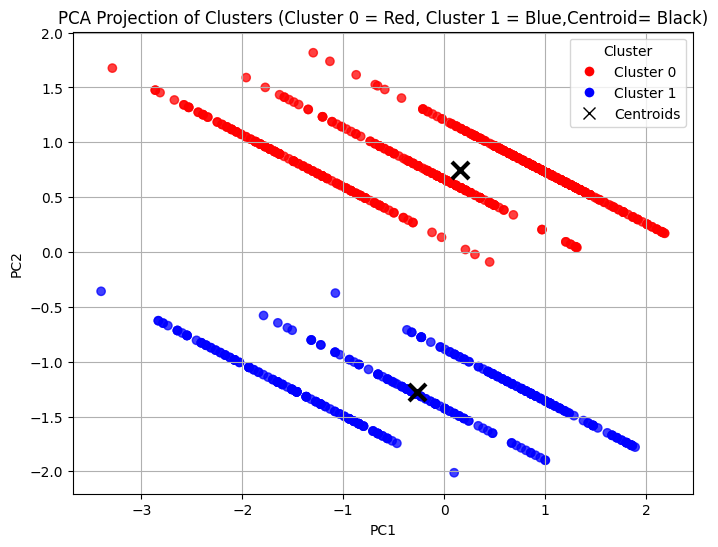

In [109]:
# Q5.2 — PCA visualization of clustering results (Red & Blue Colors)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(cluster_scaled)


# Define colors for clarity: Cluster 0 = Red, Cluster 1 = Blue
colors = ['red' if label == 0 else 'blue' for label in cluster_labels]

plt.figure(figsize=(8,6))
scatter = plt.scatter(pcs[:,0], pcs[:,1], c=colors, alpha=0.75)
centroid_pca=pca.transform(kmeans.cluster_centers_)
plt.scatter(centroid_pca[:,0], centroid_pca[:,1], marker='x', s=150,c="black", linewidths=3, label='Centroids') # Added label for legend

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection of Clusters (Cluster 0 = Red, Cluster 1 = Blue,Centroid= Black)')
plt.grid(True)

plt.legend(handles=handles, title="Cluster")

plt.show()

In [110]:
# Q5.3 — Silhouette score for cluster evaluation

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(cluster_scaled, cluster_labels)
print("Silhouette Score:", round(sil_score, 4))


Silhouette Score: 0.3945


In [111]:
# Q5.4 — Cross-tab survival vs cluster

comparison = pd.crosstab(clustered['cluster'], clustered['survived'])
print(comparison)


survived    0    1
cluster           
0         523  135
1          96  292
